# Movie Review Classification on IMDB Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
src = list(files.upload().values())[0]
open('utils.py','wb').write(src)

Saving utils.py to utils.py


2755

In [ ]:
# import libraries
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing import text_dataset_from_directory
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import KeyedVectors
import utils
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling1D, Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

## Load and preprocess the data

In [ ]:
# load the dataset
train_ds = text_dataset_from_directory('/content/drive/MyDrive/IMDB_Data/aclImdb/train')
test_ds = text_dataset_from_directory('/content/drive/MyDrive/IMDB_Data/aclImdb/test')

Found 25000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


In [ ]:
# prepare train and test dataframes
train_df = pd.DataFrame(train_ds.unbatch().as_numpy_iterator(), columns=['text', 'label'])
test_df = pd.DataFrame(test_ds.unbatch().as_numpy_iterator(), columns=['text', 'label'])

In [ ]:
# preprocess the dataset
_, xts = train_test_split(test_df, stratify=test_df['label'], test_size=0.25)

train_df['text'] = train_df['text'].map(lambda x: x.decode())
xts['text'] = xts['text'].map(lambda x: x.decode())

In [ ]:
# view 5 training samples
pd.options.display.max_colwidth = 200
train_df.sample(n=5)

,text,label
24037,"Playwright Sidney Bruhl (Michael Caine) has had a series of flop plays after a huge hit. He receives a play written by a student of his, Clifford Anderson (Christopher Reeve) which is fantastic. I...",1
8670,"Jimmy Cagney races by your eyes constantly in this story of a stage-producer who is vigorously struggling against the upcoming ""talking"" movies.<br /><br />This story of love, deceit, women and da...",1
18635,"I saw ""Brother's Shadow"" at the Tribeca Film Festival and found myself still thinking about it two days later. The story of a prodigal son (Scott Cohen) returning to his family's custom furniture ...",1
14229,"If you a purist, don't waste your time - otherwise, hold onto your hat and enjoy the adventure. I loved the Stewart Granger/Deborah Kerr version - I've seen it dozens of times, but this film is ev...",1
19837,"A surprisingly complex and well crafted study of ""The First"" serial killer in the USSR. Set in the days of perestroika this intense piece is brought to full life with the performances of Stephen R...",1


In [ ]:
# print a movie review
print(train_df.loc[0, 'text'])

It was hard to watch this film and be totally fair and objective since I am a big fan the original 1944 movie. That, to me and many others, is one of the greatest film noirs ever made. Realizing this is simply a shortened made-for-TV film and that most people had trashed it, I didn't expect much, but you can't help but compare this with the '44 film. Scene after scene, I found myself comparing what I was looking at it, and remembering how it played out with Fred MacMurray, Barbara Stanwyck, Edward G. Robinson and others. Now I was seeing these famous actors playing their famous roles replaced by Richard Crenna, Samantha Eggar and Lee J. Cobb.<br /><br />When it was all over, I found it wasn't as bad as I had expected but it's no match for the 1944 original. The two main areas in which this made-for-TV film wasn't as good were (1) the electricity between the two leads was missing and (2) being only 90 minutes, they rushed the story with hardly time to develop the plot, characters and ch

## Tokenize the text

In [ ]:
# init tokenizer
tokenizer = Tokenizer()

# fit text into tokenizer
tokenizer.fit_on_texts(train_df['text'].tolist())

In [ ]:
# prepare train and test sequences
train_sequences = tokenizer.texts_to_sequences(train_df['text'].tolist())
test_sequences = tokenizer.texts_to_sequences(xts['text'].tolist())

word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

Found 88582 unique tokens.


In [ ]:
# compute max_sequence length for padding
max_train_seq_len = max([len(seq) for seq in train_sequences])
max_test_seq_len = max([len(seq) for seq in test_sequences])
max_sequence_len = max(max_train_seq_len, max_test_seq_len)
max_sequence_len

2493

In [ ]:
# padding
train_data = pad_sequences(train_sequences, maxlen = max_sequence_len)
test_data = pad_sequences(test_sequences, maxlen = max_sequence_len)

## Train classifier with word embeddings

In [ ]:
# load pre-trained model from previous session on contries wiki data
countries_wiki = KeyedVectors.load('/content/sample_data/wiki-countries.w2v')

In [ ]:
# make embedding layer
embedding_layer = utils.make_embedding_layer(countries_wiki, tokenizer, max_sequence_len)

In [ ]:
# build NN model
countries_wiki_model = Sequential()

countries_wiki_model.add(Input(shape=(max_sequence_len, ), dtype='int32'))
countries_wiki_model.add(embedding_layer)
countries_wiki_model.add(GlobalAveragePooling1D())
countries_wiki_model.add(Dense(128, activation='relu'))
countries_wiki_model.add(Dense(64, activation='relu'))
countries_wiki_model.add(Dense(1, activation='sigmoid'))

countries_wiki_model.compile(loss = 'binary_crossentropy', optimizer=Adam(), metrics = ['accuracy'])

In [ ]:
# train model
model_history = countries_wiki_model.fit(train_data, train_df['label'].values,
                                         validation_data=(test_data, xts['label']),
                                         batch_size=64, epochs=30)

Epoch 1/30
391/391 [==============================] - 9s 22ms/step - loss: 0.6141 - accuracy: 0.6644 - val_loss: 0.5691 - val_accuracy: 0.7158
Epoch 2/30
391/391 [==============================] - 8s 21ms/step - loss: 0.5496 - accuracy: 0.7242 - val_loss: 0.5611 - val_accuracy: 0.7258
Epoch 3/30
391/391 [==============================] - 8s 21ms/step - loss: 0.5278 - accuracy: 0.7392 - val_loss: 0.5302 - val_accuracy: 0.7381
Epoch 4/30
391/391 [==============================] - 8s 21ms/step - loss: 0.5202 - accuracy: 0.7395 - val_loss: 0.5291 - val_accuracy: 0.7374
Epoch 5/30
391/391 [==============================] - 8s 22ms/step - loss: 0.5136 - accuracy: 0.7458 - val_loss: 0.5204 - val_accuracy: 0.7437
Epoch 6/30
391/391 [==============================] - 9s 22ms/step - loss: 0.5091 - accuracy: 0.7479 - val_loss: 0.5208 - val_accuracy: 0.7454
Epoch 7/30
391/391 [==============================] - 9s 22ms/step - loss: 0.5050 - accuracy: 0.7506 - val_loss: 0.5327 - val_accuracy: 0.7341

## Train classifier with different sets of word embeddings

In [ ]:
glove_wiki = KeyedVectors.load_word2vec_format('/content/sample_data/glove.6B.50d.txt', binary = False, no_header = True)

In [ ]:
# make embedding layer
glove_embedding_layer = utils.make_embedding_layer(glove_wiki, tokenizer, max_sequence_len)

In [ ]:
# build NN model
glove_wiki_model = Sequential()

glove_wiki_model.add(Input(shape=(max_sequence_len, ), dtype='int32'))
glove_wiki_model.add(embedding_layer)
glove_wiki_model.add(GlobalAveragePooling1D())
glove_wiki_model.add(Dense(128, activation='relu'))
glove_wiki_model.add(Dense(64, activation='relu'))
glove_wiki_model.add(Dense(1, activation='sigmoid'))

glove_wiki_model.compile(loss = 'binary_crossentropy', optimizer=Adam(), metrics = ['accuracy'])

In [ ]:
# train model
model2_history = glove_wiki_model.fit(train_data, train_df['label'].values,
                                         validation_data=(test_data, xts['label']),
                                         batch_size=64, epochs=30)

Epoch 1/30
391/391 [==============================] - 9s 22ms/step - loss: 0.6143 - accuracy: 0.6685 - val_loss: 0.5705 - val_accuracy: 0.7186
Epoch 2/30
391/391 [==============================] - 8s 22ms/step - loss: 0.5467 - accuracy: 0.7276 - val_loss: 0.5474 - val_accuracy: 0.7296
Epoch 3/30
391/391 [==============================] - 9s 22ms/step - loss: 0.5304 - accuracy: 0.7366 - val_loss: 0.5307 - val_accuracy: 0.7406
Epoch 4/30
391/391 [==============================] - 8s 21ms/step - loss: 0.5191 - accuracy: 0.7432 - val_loss: 0.5299 - val_accuracy: 0.7355
Epoch 5/30
391/391 [==============================] - 8s 22ms/step - loss: 0.5161 - accuracy: 0.7430 - val_loss: 0.5186 - val_accuracy: 0.7435
Epoch 6/30
391/391 [==============================] - 9s 22ms/step - loss: 0.5089 - accuracy: 0.7476 - val_loss: 0.5173 - val_accuracy: 0.7435
Epoch 7/30
391/391 [==============================] - 8s 22ms/step - loss: 0.5059 - accuracy: 0.7487 - val_loss: 0.5172 - val_accuracy: 0.7462

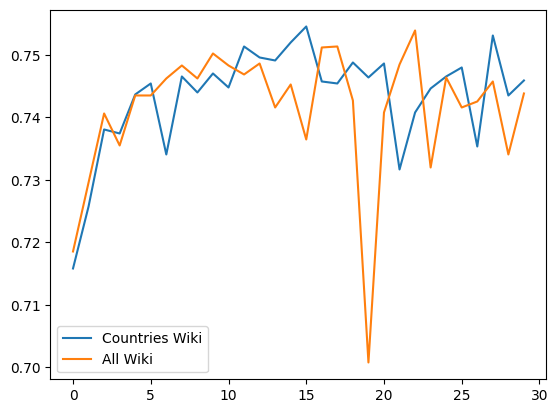

In [ ]:
plt.plot(model_history.history['val_accuracy'], label='Countries Wiki')
plt.plot(model2_history.history['val_accuracy'], label='All Wiki')
plt.legend()